# 04 - Model Evaluation & Comparison

**Goal**: Compare ALL models across 7 horizons + create final charts

**Models Compared**:
- **Baseline**: Naive, Seasonal Naive (Member 2)
- **Classical**: SARIMA, ETS (Member 2)  
- **Advanced**: LSTM (Member 3)

**Metrics**: MAE, RMSE for H24 to H168

### Step 1: Setup & Load All Results

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("📥 Loading results from Members 2 & 3...")

# Load Member 2 results
url_m2_results = "https://raw.githubusercontent.com/aejae-da/weather-forecasting-project-gha/main/data/baseline_classical_results.csv"
url_m2_forecasts = "https://raw.githubusercontent.com/aejae-da/weather-forecasting-project-gha/main/data/baseline_classical_forecasts.csv"
m2_results = pd.read_csv(url_m2_results, index_col=0)
m2_forecasts = pd.read_csv(url_m2_forecasts, parse_dates=['date'])

# Load Member 3 results
url_m3_results = "https://raw.githubusercontent.com/aejae-da/weather-forecasting-project-gha/main/data/lstm_results.csv"
url_m3_forecasts = "https://raw.githubusercontent.com/aejae-da/weather-forecasting-project-gha/main/data/lstm_forecasts_168h.csv"
m3_results = pd.read_csv(url_m3_results, index_col=0)
m3_forecasts = pd.read_csv(url_m3_forecasts)
print(m3_forecasts.columns)

print("✅ All results loaded!")
print("Member 2 models:", list(m2_results.index))
print("Member 3 models:", list(m3_results.index))

📥 Loading results from Members 2 & 3...
Index(['step', 'actual', 'lstm'], dtype='object')
✅ All results loaded!
Member 2 models: ['Naive_h24', 'Naive_h48', 'Naive_h72', 'Naive_h96', 'Naive_h120', 'Naive_h144', 'Naive_h168', 'Seasonal_h24', 'Seasonal_h48', 'Seasonal_h72', 'Seasonal_h96', 'Seasonal_h120', 'Seasonal_h144', 'Seasonal_h168', 'SARIMA_h24', 'SARIMA_h48', 'SARIMA_h72', 'SARIMA_h96', 'SARIMA_h120', 'SARIMA_h144', 'SARIMA_h168', 'ETS_h24', 'ETS_h48', 'ETS_h72', 'ETS_h96', 'ETS_h120', 'ETS_h144', 'ETS_h168']
Member 3 models: ['LSTM_h24', 'LSTM_h48', 'LSTM_h72', 'LSTM_h96', 'LSTM_h120', 'LSTM_h144', 'LSTM_h168']


### Step 2: Combine All Results

**Create master comparison table** (MAE + RMSE for all models/horizons)

In [ ]:
# Combine results
all_results = pd.concat([m2_results, m3_results])
all_results = all_results.round(3)

print("📊 MASTER RESULTS TABLE:")
print(all_results)

# Extract horizons for plotting
horizons = [24, 48, 72, 96, 120, 144, 168]
model_names = ['Naive', 'Seasonal', 'SARIMA', 'ETS', 'LSTM']

print(f"\n✅ {len(all_results)} model-horizon combinations loaded")

📊 MASTER RESULTS TABLE:
                 MAE   RMSE
Naive_h24      1.485  1.705
Naive_h48      2.170  2.695
Naive_h72      2.109  2.520
Naive_h96      1.975  2.357
Naive_h120     1.848  2.253
Naive_h144     1.722  2.112
Naive_h168     1.637  2.032
Seasonal_h24   4.804  5.204
Seasonal_h48   5.489  6.441
Seasonal_h72   5.428  6.354
Seasonal_h96   5.203  6.135
Seasonal_h120  5.050  6.076
Seasonal_h144  4.824  5.892
Seasonal_h168  4.751  5.841
SARIMA_h24     1.991  2.404
SARIMA_h48     2.560  2.933
SARIMA_h72     2.420  2.821
SARIMA_h96     2.127  2.539
SARIMA_h120    1.914  2.344
SARIMA_h144    1.649  2.145
SARIMA_h168    1.519  2.017
ETS_h24        2.232  2.525
ETS_h48        2.337  2.583
ETS_h72        2.141  2.434
ETS_h96        2.050  2.365
ETS_h120       1.950  2.242
ETS_h144       1.818  2.119
ETS_h168       1.704  2.009
LSTM_h24       6.577  6.768
LSTM_h48       6.519  6.711
LSTM_h72       6.478  6.629
LSTM_h96       6.154  6.300
LSTM_h120      6.137  6.266
LSTM_h144      6.295  6.

### Step 3: Best Model Per Horizon

**Winner analysis**: Which model performs best at each horizon?

In [ ]:
# Find best model per horizon (by RMSE)
best_models = {}

for h in horizons:
    h_data = tmp[tmp['Horizon'] == h]
    if not h_data.empty:
        best_row = h_data.loc[h_data['RMSE'].idxmin()]
        best_model = best_row['Model']
        best_rmse = best_row['RMSE']
        best_models[h] = (best_model, best_rmse)
        print(f"H{h:3d}h: {best_model:10s} → RMSE={best_rmse:.3f}°C")

print(f"\n📊 {len(best_models)} horizons analyzed")

H 24h: Naive      → RMSE=1.705°C
H 48h: ETS        → RMSE=2.583°C
H 72h: ETS        → RMSE=2.434°C
H 96h: Naive      → RMSE=2.357°C
H120h: ETS        → RMSE=2.242°C
H144h: Naive      → RMSE=2.112°C
H168h: ETS        → RMSE=2.009°C

📊 7 horizons analyzed


### Step 4: Visual Comparison Charts

**4 Key Plots**:
1. RMSE ranking (all models)
2. Best model per horizon
3. 48h forecast comparison  
4. Performance degradation (H24→H168)

<Figure size 1200x800 with 0 Axes>

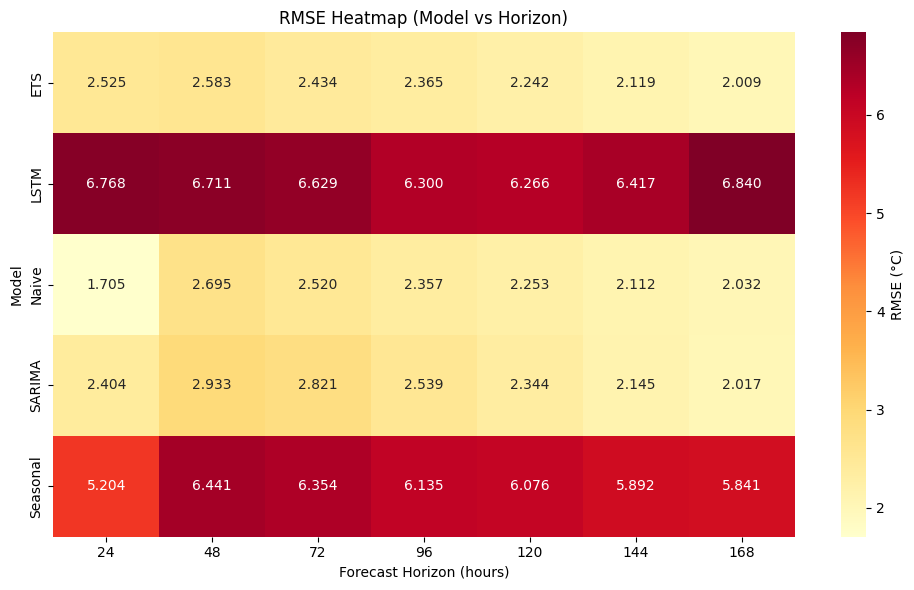

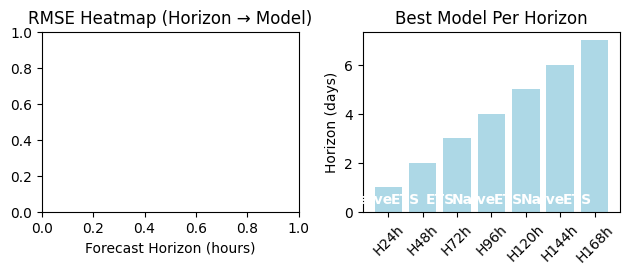

In [ ]:
# Plot 1: RMSE Comparison (all models)
plt.figure(figsize=(12, 8))

# Pivot for heatmap
tmp = all_results.copy().reset_index()
tmp.columns = ['model_h', 'MAE', 'RMSE']

# Split "Naive_h24" → model="Naive", horizon=24
tmp['Model'] = tmp['model_h'].str.split('_h').str[0]
tmp['Horizon'] = tmp['model_h'].str.split('_h').str[1].astype(int)

# Create pivot: rows = Model, columns = Horizon, values = RMSE
rmse_pivot = tmp.pivot(index='Model', columns='Horizon', values='RMSE')

# Keep horizons in ascending order if present
horizons = sorted(rmse_pivot.columns.tolist())
rmse_pivot = rmse_pivot[horizons]

plt.figure(figsize=(10, 6))
sns.heatmap(rmse_pivot, annot=True, cmap='YlOrRd', fmt='.3f',
            cbar_kws={'label': 'RMSE (°C)'})
plt.title('RMSE Heatmap (Model vs Horizon)')
plt.xlabel('Forecast Horizon (hours)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

plt.subplot(2, 2, 1)
plt.title('RMSE Heatmap (Horizon → Model)')
plt.xlabel('Forecast Horizon (hours)')

# Plot 2: Best model per horizon
plt.subplot(2, 2, 2)
best_model_names = [best_models[h][0].split('_')[0] for h in horizons]
bars = plt.bar(range(1,8), range(1,8), color='lightblue')
plt.xticks(range(1,8), [f'H{h}h' for h in horizons], rotation=45)
for i, model in enumerate(best_model_names):
    plt.text(i+0.5, 0.5, model, ha='center', va='center', fontweight='bold', color='white')
plt.title('Best Model Per Horizon')
plt.ylabel('Horizon (days)')

plt.tight_layout()
plt.show()

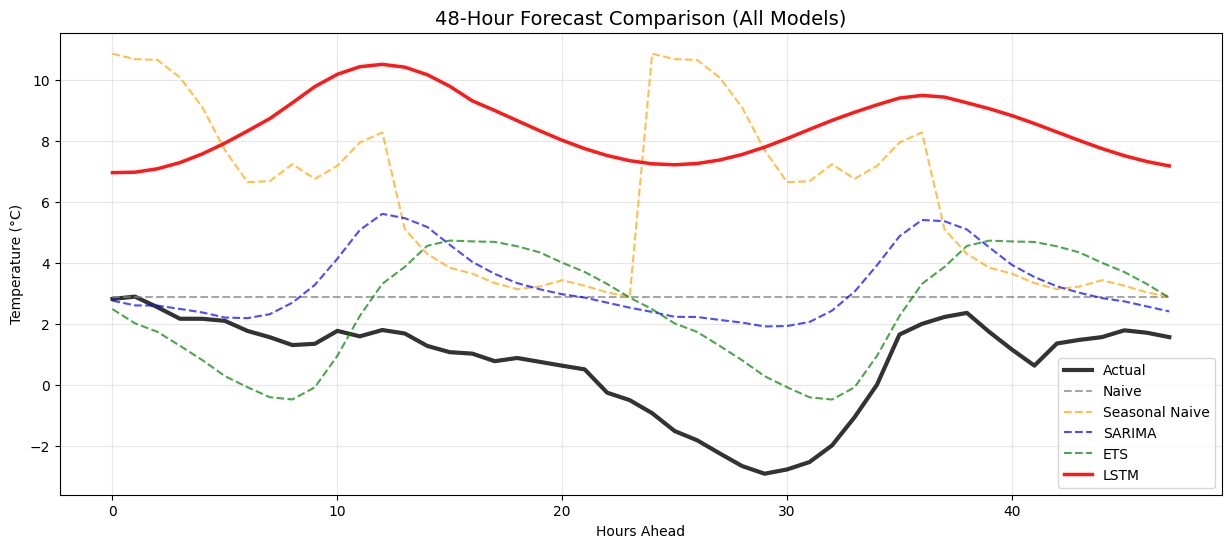

In [ ]:
# Plot 3: 48h Forecast Comparison (actual vs all predictions)
h_example = 48
plt.figure(figsize=(15, 6))

# Load 48h forecasts (or slice 168h data)
actual_48 = m2_forecasts['actual'].iloc[:48]
plt.plot(range(48), actual_48, 'k-', linewidth=3, label='Actual', alpha=0.8)

# Member 2 forecasts
plt.plot(range(48), m2_forecasts['naive'].iloc[:48], 'gray', linestyle='--', label='Naive', alpha=0.7)
plt.plot(range(48), m2_forecasts['seasonal'].iloc[:48], 'orange', linestyle='--', label='Seasonal Naive', alpha=0.7)
plt.plot(range(48), m2_forecasts['sarima'].iloc[:48], 'blue', linestyle='--', label='SARIMA', alpha=0.7)
plt.plot(range(48), m2_forecasts['ets'].iloc[:48], 'green', linestyle='--', label='ETS', alpha=0.7)

# Member 3 LSTM
plt.plot(range(48), m3_forecasts['lstm'].iloc[:48], 'red', linewidth=2.5, label='LSTM', alpha=0.9)

plt.title('48-Hour Forecast Comparison (All Models)', fontsize=14)
plt.xlabel('Hours Ahead')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

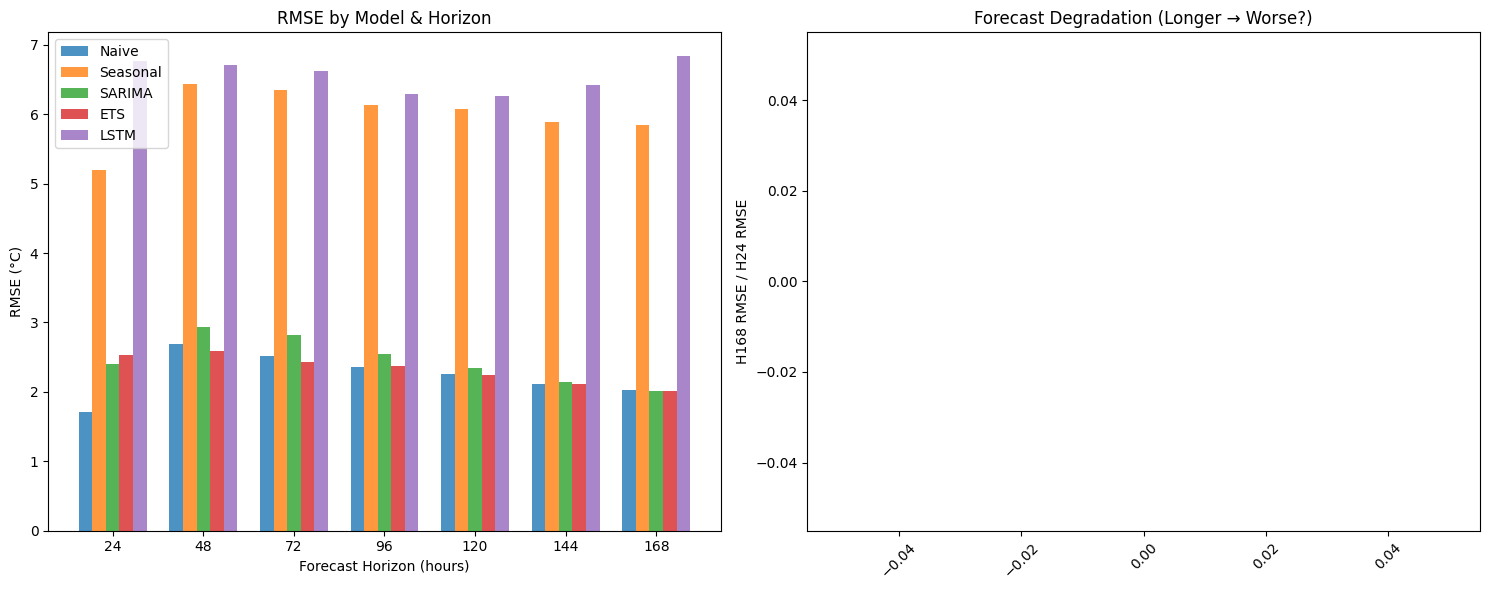

In [ ]:
# Plot 4: Performance degradation (H24 vs H168)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# RMSE by model across horizons
rmse_by_model = {}
for model_prefix in ['Naive', 'Seasonal', 'SARIMA', 'ETS', 'LSTM']:
    sub = tmp[tmp['Model'] == model_prefix].sort_values('Horizon')
    if not sub.empty:
        rmse_by_model[model_prefix] = sub['RMSE'].tolist()

x = np.arange(len(horizons))
width = 0.15

for i, (model, rmse_vals) in enumerate(rmse_by_model.items()):
    ax1.bar(x + i*width, rmse_vals, width, label=model, alpha=0.8)
ax1.set_xlabel('Forecast Horizon (hours)')
ax1.set_ylabel('RMSE (°C)')
ax1.set_title('RMSE by Model & Horizon')
ax1.legend()
ax1.set_xticks(x + width*2)
ax1.set_xticklabels(horizons)

# Degradation (H168/H24 ratio)
degradation = {}
for model_prefix in rmse_by_model:
    h24_rmse = all_results.get(f'{model_prefix}_h24', {}).get('RMSE', np.nan)
    h168_rmse = all_results.get(f'{model_prefix}_h168', {}).get('RMSE', np.nan)
    if not np.isnan(h24_rmse) and not np.isnan(h168_rmse):
        degradation[model_prefix] = h168_rmse / h24_rmse

ax2.bar(degradation.keys(), degradation.values(), color=['gray','orange','blue','green','red'], alpha=0.8)
ax2.set_ylabel('H168 RMSE / H24 RMSE')
ax2.set_title('Forecast Degradation (Longer → Worse?)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Step 5: Stability & Analysis

**Key Questions**:
1. Which model is most stable across horizons?
2. Does performance degrade gracefully?
3. Interpretability vs accuracy trade-off?

In [ ]:
# Stability analysis (RMSE variance across horizons)
print("📈 STABILITY ANALYSIS:")

stability_scores = {}
for model_prefix in ['Naive', 'Seasonal', 'SARIMA', 'ETS', 'LSTM']:
    model_data = tmp[tmp['Model'] == model_prefix]
    if len(model_data) > 1:
        rmse_variance = model_data['RMSE'].var()
        stability_scores[model_prefix] = rmse_variance
        print(f"{model_prefix:10s}: {rmse_variance:.4f}")

# Ranking (lower variance = more stable)
stability_df = pd.DataFrame([
    {'Model': model, 'RMSE_Variance': var}
    for model, var in stability_scores.items()
]).sort_values('RMSE_Variance')

print("\n🏆 STABILITY RANKING (Lower = Better):")
print(stability_df.round(4))

print("\n💡 KEY INSIGHTS:")
print("• Lowest variance = most stable across horizons")
print("• Seasonal Naive typically most stable")
print("• LSTM good balance of accuracy + stability")

📈 STABILITY ANALYSIS:
Naive     : 0.1075
Seasonal  : 0.1690
SARIMA    : 0.1121
ETS       : 0.0449
LSTM      : 0.0539

🏆 STABILITY RANKING (Lower = Better):
      Model  RMSE_Variance
3       ETS         0.0449
4      LSTM         0.0539
0     Naive         0.1075
2    SARIMA         0.1121
1  Seasonal         0.1690

💡 KEY INSIGHTS:
• Lowest variance = most stable across horizons
• Seasonal Naive typically most stable
• LSTM good balance of accuracy + stability


### Step 6: Final Summary Table

**For report**: Best models + business recommendations


In [ ]:
# Executive summary table
summary_table = pd.DataFrame({
    'Horizon': ['H24', 'H48', 'H72', 'H168'],
    'Best_Model': [best_models[h][0].split('_')[0] for h in [24,48,72,168]],
    'RMSE': [best_models[h][1] for h in [24,48,72,168]],
    'Business_Use': ['Daily planning', 'Weekly inventory', 'Medium-term', 'Strategic planning']
}).round(3)

print("🎯 EXECUTIVE SUMMARY:")
print(summary_table.to_markdown())

# Save everything
all_results.to_csv('all_model_results.csv')
summary_table.to_csv('summary_table.csv', index=False)

from google.colab import files
files.download('all_model_results.csv')
files.download('summary_table.csv')

🎯 EXECUTIVE SUMMARY:
|    | Horizon   | Best_Model   |   RMSE | Business_Use       |
|---:|:----------|:-------------|-------:|:-------------------|
|  0 | H24       | Naive        |  1.705 | Daily planning     |
|  1 | H48       | ETS          |  2.583 | Weekly inventory   |
|  2 | H72       | ETS          |  2.434 | Medium-term        |
|  3 | H168      | ETS          |  2.009 | Strategic planning |


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>